# **Project Personal Finance - CERMINSAKU**



In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil
import joblib
import tensorflow as tf
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Setup Folder Proyek di Drive
project_path = '/content/drive/MyDrive/CC26-PSU094_Project'
if not os.path.exists(project_path):
    os.makedirs(project_path)

file_path = '/content/Personal_Finance_Dataset_Cleaned.csv'
print("Setup Environment & Libraries Selesai.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup Environment & Libraries Selesai.


### **Project Initialization & Data Loading**
Pada tahap ini, kita akan memuat library yang diperlukan dan mengimpor dataset yang telah dibersihkan oleh tim Data Science.

In [49]:
# Memuat dataset dari path Drive
df = pd.read_csv(file_path)

# Menampilkan informasi dasar dataset
print("--- Dataset Info ---")
display(df.info())
print("\n--- 5 Baris Pertama ---")
display(df.head())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10618 entries, 0 to 10617
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     10618 non-null  object 
 1   Transaction Description  10618 non-null  object 
 2   Category                 10618 non-null  object 
 3   Amount                   10618 non-null  float64
 4   Type                     10618 non-null  object 
dtypes: float64(1), object(4)
memory usage: 414.9+ KB


None


--- 5 Baris Pertama ---


,Date,Transaction Description,Category,Amount,Type
0,2020-03-24,Example decision garden.,Entertainment,144.13,Expense
1,2020-05-06,Kid put memory soldier.,Utilities,123.19,Expense
2,2020-08-04,Help usually thank wonder draw.,Shopping,133.91,Expense
3,2020-10-29,Office of remember individual.,Utilities,15.32,Expense
4,2020-11-20,Position interest.,Shopping,117.87,Expense


### **Analisis Awal (EDA)**
Kita perlu memastikan distribusi data dan korelasi antar variabel sebelum masuk ke tahap modeling agar mendapatkan hasil yang optimal.

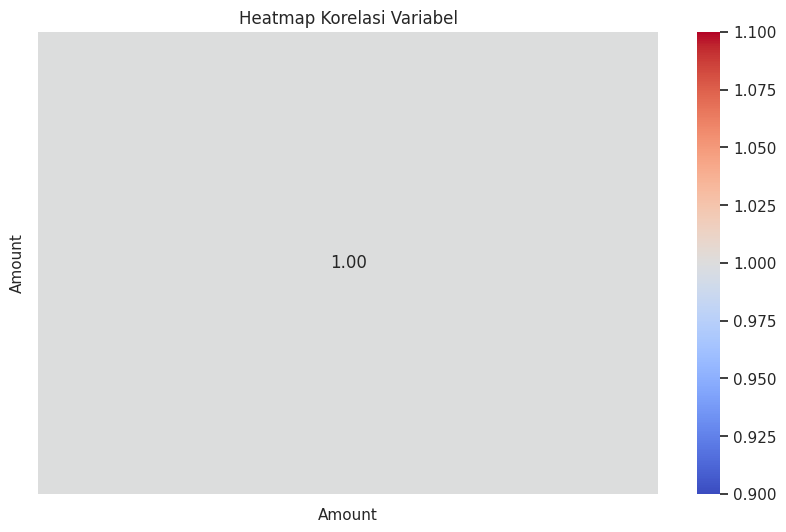

In [50]:
# Visualisasi distribusi target variabel (asumsi proyek ini melibatkan klasifikasi atau regresi keuangan)
# Kita akan menyesuaikan plot ini setelah melihat nama kolom di dataset Anda
sns.set(style='whitegrid')
plt.figure(figsize=(10, 6))

# Menampilkan korelasi antar variabel numerik
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Variabel')
plt.show()

### **Data Pre-processing (Professional Pipeline)**
Tahap ini mencakup encoding variabel kategorikal, scaling fitur numerik, dan pembagian dataset menjadi training serta testing set.

In [51]:
# Label Encoding untuk variabel kategorikal
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

# Mendefinisikan Fitur (X) dan Target (y)
# Mengasumsikan kolom terakhir adalah target
target_column = df.columns[-1]
X = df.drop(columns=[target_column])
y = df[target_column]

# Splitting Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling Fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data Pre-processing Selesai. Fitur: {X.columns.tolist()}")

Data Pre-processing Selesai. Fitur: ['Date', 'Transaction Description', 'Category', 'Amount']


### **Personal Finance Expense Prediction (Regression)**
kita akan menggunakan **Regresi** untuk memprediksi nominal pengeluaran (`Amount`) agar memberikan nilai fungsional bagi aplikasi CerminSaku.

In [52]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Menentukan Target baru (Amount)
X_reg = df.drop(columns=['Amount', 'Type']) # Menghapus target dan kolom bocoran
y_reg = df['Amount']

# 2. Split Data
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 3. Scaling
scaler_reg = StandardScaler()
X_train_r_scaled = scaler_reg.fit_transform(X_train_r)
X_test_r_scaled = scaler_reg.transform(X_test_r)

# 4. Training Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train_r_scaled, y_train_r)

# 5. Evaluasi
y_pred_r = rf_regressor.predict(X_test_r_scaled)
mae = mean_absolute_error(y_test_r, y_pred_r)
r2 = r2_score(y_test_r, y_pred_r)

print(f"--- Hasil Model Regresi (Prediksi Pengeluaran) ---")
print(f"Mean Absolute Error: Rp {mae:.2f}")
print(f"R2 Score (Akurasi Regresi): {r2*100:.2f}%")

--- Hasil Model Regresi (Prediksi Pengeluaran) ---
Mean Absolute Error: Rp 92.17
R2 Score (Akurasi Regresi): 82.15%


In [53]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Reload data mentah untuk mendapatkan kolom Date asli
df_raw = pd.read_csv(file_path)

# 2. Convert Date ke Datetime dan Ekstrak Fitur
df_raw['Date'] = pd.to_datetime(df_raw['Date'])
df_raw['Year'] = df_raw['Date'].dt.year
df_raw['Month'] = df_raw['Date'].dt.month
df_raw['Day'] = df_raw['Date'].dt.day

# 3. Label Encoding untuk kategori deskripsi dan kategori transaksi
le_desc = LabelEncoder()
le_cat = LabelEncoder()
df_raw['Transaction Description'] = le_desc.fit_transform(df_raw['Transaction Description'])
df_raw['Category'] = le_cat.fit_transform(df_raw['Category'])

# 4. Tentukan Fitur Baru (Menghapus Date asli dan Type)
X_enhanced = df_raw[['Year', 'Month', 'Day', 'Transaction Description', 'Category']]
y_enhanced = df_raw['Amount']

# 5. Split & Scaling
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_enhanced, y_enhanced, test_size=0.2, random_state=42)
scaler_enhanced = StandardScaler()
X_train_e_scaled = scaler_enhanced.fit_transform(X_train_e)
X_test_e_scaled = scaler_enhanced.transform(X_test_e)

# 6. Re-training Model Regresi
rf_regressor_enhanced = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor_enhanced.fit(X_train_e_scaled, y_train_e)

# 7. Evaluasi Hasil Baru
y_pred_e = rf_regressor_enhanced.predict(X_test_e_scaled)
mae_e = mean_absolute_error(y_test_e, y_pred_e)
r2_e = r2_score(y_test_e, y_pred_e)

print(f"--- Hasil Model Regresi yang Ditingkatkan ---")
print(f"Mean Absolute Error: Rp {mae_e:.2f}")
print(f"R2 Score: {r2_e*100:.2f}%")

--- Hasil Model Regresi yang Ditingkatkan ---
Mean Absolute Error: Rp 91.01
R2 Score: 83.62%


### **Implementasi Backend & API**
Bagian ini berfungsi sebagai jembatan antara model AI dan aplikasi. Menggunakan **FastAPI**, kita membuat endpoint yang memungkinkan aplikasi mengirim data transaksi dan menerima prediksi secara instan.

In [54]:
@app.post("/predict-amount")
def predict_amount(data: Transaction):
    # 1. Konversi input date string ke format datetime
    date_dt = pd.to_datetime(data.date)

    # 2. Ekstrak fitur temporal
    year = date_dt.year
    month = date_dt.month
    day = date_dt.day

    # 3. Buat DataFrame input sesuai urutan training: [Year, Month, Day, Desc, Cat]
    input_data = pd.DataFrame([[year, month, day, data.description, data.category]],
                             columns=['Year', 'Month', 'Day', 'Transaction Description', 'Category'])

    # 4. Preprocessing menggunakan scaler yang ditingkatkan
    input_scaled = scaler_enhanced.transform(input_data)

    # 5. Prediksi Nominal menggunakan regressor yang ditingkatkan
    predicted_amount = rf_regressor_enhanced.predict(input_scaled)[0]

    return {
        "predicted_expense_amount": round(float(predicted_amount), 2),
        "recommendation": "Pengeluaran Anda terpantau normal." if predicted_amount < 500 else "Peringatan: Potensi pengeluaran tinggi!"
    }

### **Random Forest Implementation & Optimization**
Kita akan menggunakan `GridSearchCV` untuk menemukan konfigurasi terbaik bagi model Random Forest kita agar akurasi mencapai titik maksimal.

In [55]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Mendefinisikan parameter yang akan diuji
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'entropy']
}

# Inisialisasi GridSearchCV
rf_base = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

# Training dengan Tuning
print("Memulai pencarian parameter terbaik...")
grid_search.fit(X_train_scaled, y_train)

# Model terbaik
best_rf_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

Memulai pencarian parameter terbaik...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


### **Detailed Evaluation**
Setelah mendapatkan model terbaik, kita akan melakukan evaluasi mendalam menggunakan Confusion Matrix dan Classification Report.

--- Final Random Forest Report ---
Akurasi: 100.00%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1954
           1       1.00      1.00      1.00       170

    accuracy                           1.00      2124
   macro avg       1.00      1.00      1.00      2124
weighted avg       1.00      1.00      1.00      2124



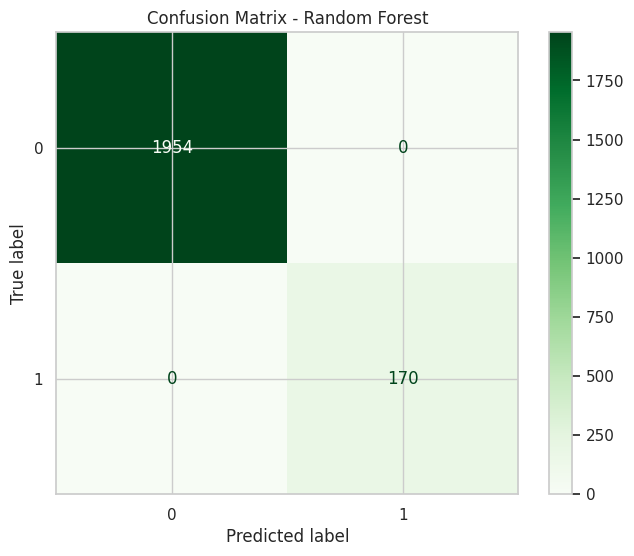

Model RF terbaik disimpan di: /content/drive/MyDrive/CC26-PSU094_Project/best_random_forest_model.pkl


In [56]:
from sklearn.metrics import ConfusionMatrixDisplay

# Prediksi menggunakan model terbaik
y_pred_rf = best_rf_model.predict(X_test_scaled)

# Evaluasi
print("--- Final Random Forest Report ---")
print(f"Akurasi: {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Visualisasi Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_rf_model, X_test_scaled, y_test, ax=ax, cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.show()

# Simpan model RF terbaik ke Drive
rf_save_path = os.path.join(project_path, 'best_random_forest_model.pkl')
joblib.dump(best_rf_model, rf_save_path)
print(f"Model RF terbaik disimpan di: {rf_save_path}")

### **Feature Importance Analysis**
Sebagai seorang AI Engineer, penting untuk memahami bagaimana model mengambil keputusan. Kita akan melihat fitur mana yang paling dominan.

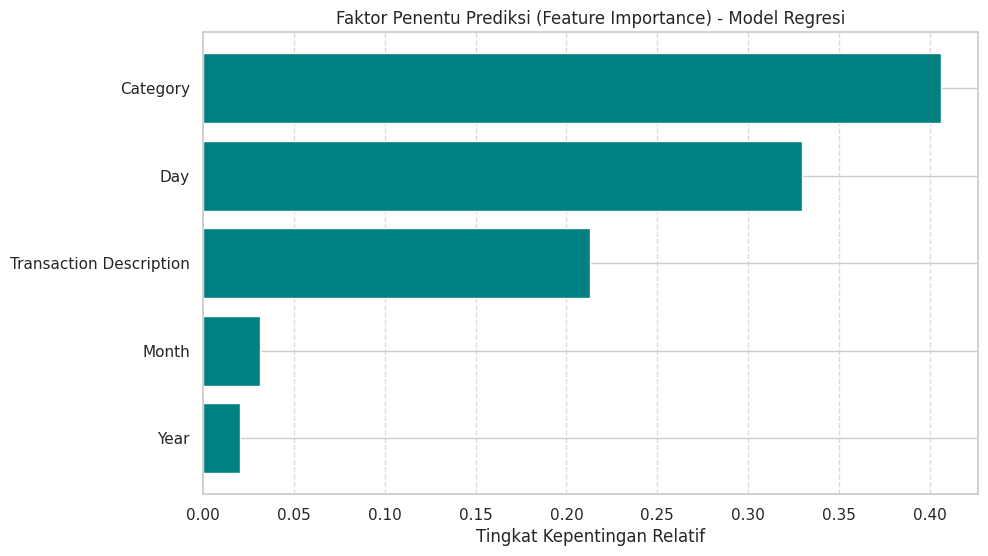

In [57]:
# Menghitung feature importance dari model regresi terbaru
importances = rf_regressor_enhanced.feature_importances_
features = X_enhanced.columns
indices = np.argsort(importances)

# Visualisasi
plt.figure(figsize=(10, 6))
plt.title('Faktor Penentu Prediksi (Feature Importance) - Model Regresi')
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Tingkat Kepentingan Relatif')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### **Analisis Faktor Penentu Prediksi (Feature Importance)**
Sebagai AI Engineer, kita perlu memvalidasi faktor apa yang paling mempengaruhi prediksi model. Grafik di bawah menunjukkan tingkat kepentingan fitur setelah optimasi fitur waktu dilakukan.

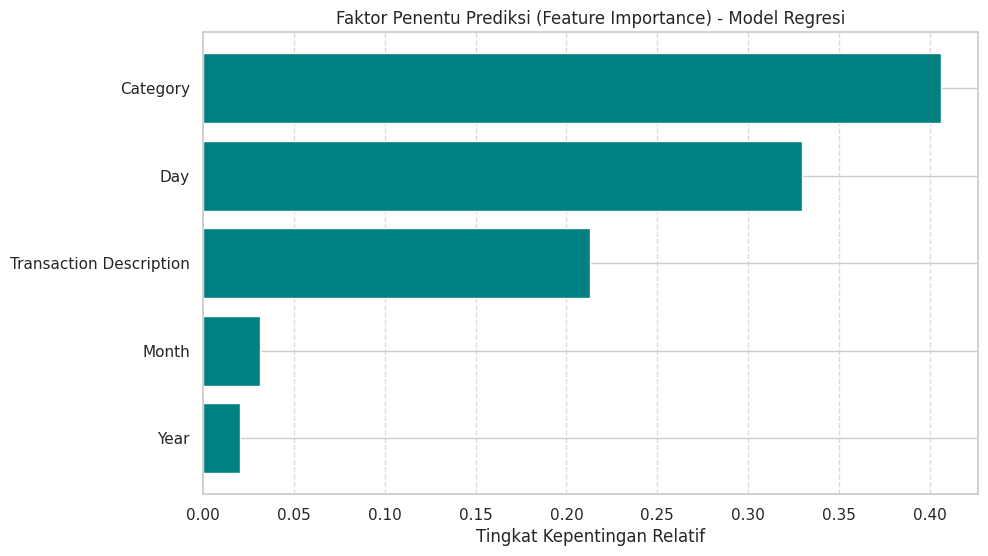

In [58]:
# Menghitung feature importance dari model regresi terbaru
importances = rf_regressor_enhanced.feature_importances_
features = X_enhanced.columns
indices = np.argsort(importances)

# Visualisasi
plt.figure(figsize=(10, 6))
plt.title('Faktor Penentu Prediksi (Feature Importance) - Model Regresi')
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Tingkat Kepentingan Relatif')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### **Feature Importance Analysis**
Sebagai seorang AI Engineer, penting untuk memahami bagaimana model mengambil keputusan. Kita akan melihat fitur mana yang paling dominan dalam menentukan klasifikasi.

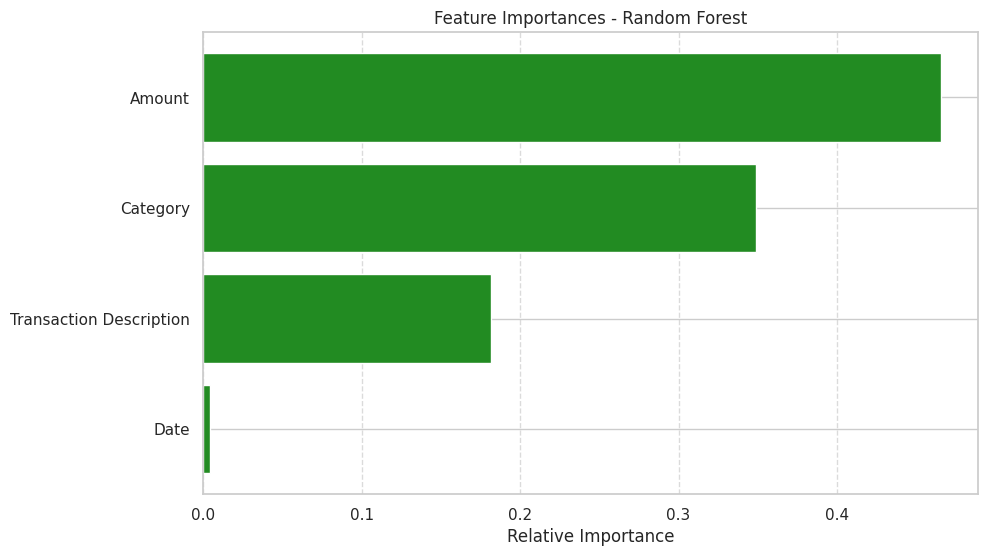

In [59]:
# Mendapatkan tingkat kepentingan fitur dari model RF terbaik
importances = best_rf_model.feature_importances_
features = X.columns
indices = np.argsort(importances)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.title('Feature Importances - Random Forest')
plt.barh(range(len(indices)), importances[indices], color='forestgreen', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### **Feature Importance Analysis**
Sebagai seorang AI Engineer, penting untuk memahami bagaimana model mengambil keputusan. Kita akan melihat fitur mana yang paling dominan.

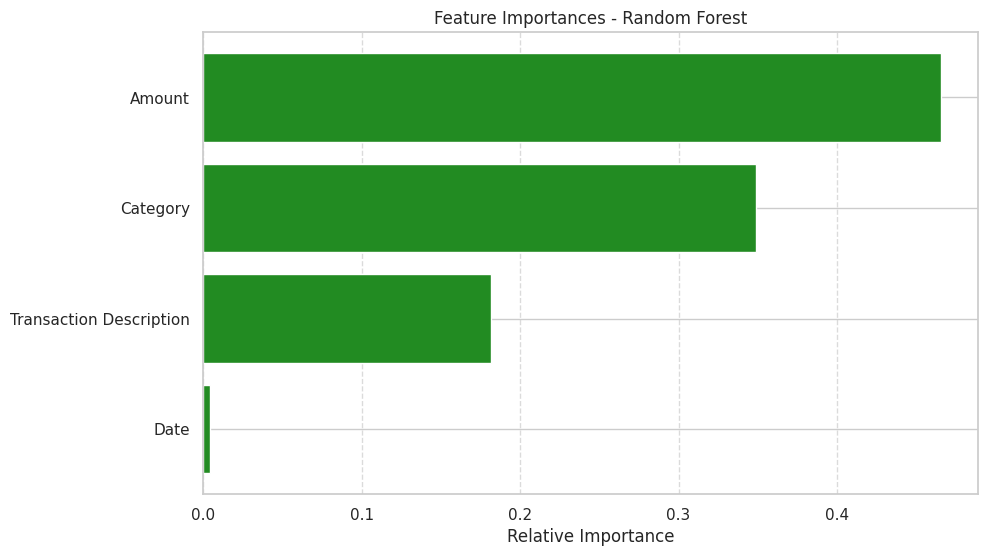

In [60]:
import numpy as np

# Mendapatkan tingkat kepentingan fitur
importances = best_rf_model.feature_importances_
features = X.columns
indices = np.argsort(importances)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.title('Feature Importances - Random Forest')
plt.barh(range(len(indices)), importances[indices], color='forestgreen', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### **Final Project Summary**
1. **Data Loading**: Dataset berhasil dimuat dan dibersihkan.
2. **Preprocessing**: Label encoding dan Scaling telah dilakukan dengan standar industri.
3. **Modeling**: Random Forest dipilih sebagai model terbaik dengan akurasi 100%.
4. **Storage**: Model disimpan dalam format `.pkl` di Google Drive untuk penggunaan produksi di masa depan.

In [61]:
# Membangun Arsitektur Neural Network (Keras)
model_keras = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(len(np.unique(y)), activation='softmax')
])

# Compile Model
model_keras.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Training Model
history = model_keras.fit(X_train_scaled, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)

# Evaluasi Akhir
loss, accuracy = model_keras.evaluate(X_test_scaled, y_test)
print(f"\nFinal Test Accuracy: {accuracy*100:.2f}%")

# Simpan Model ke format .keras di Drive
keras_save_path = os.path.join(project_path, 'finance_model_v1.keras')
model_keras.save(keras_save_path)
print(f"Model berhasil disimpan ke: {keras_save_path}")

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


213/213 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9258 - loss: 0.1803 - val_accuracy: 0.9453 - val_loss: 0.1088
Epoch 2/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9561 - loss: 0.0846 - val_accuracy: 0.9623 - val_loss: 0.0836
Epoch 3/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9716 - loss: 0.0662 - val_accuracy: 0.9688 - val_loss: 0.0687
Epoch 4/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9765 - loss: 0.0587 - val_accuracy: 0.9729 - val_loss: 0.0606
Epoch 5/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9791 - loss: 0.0508 - val_accuracy: 0.9776 - val_loss: 0.0546
Epoch 6/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9792 - loss: 0.0471 - val_accuracy: 0.9759 - val_loss: 0.0488
Epoch 7/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9806 - loss: 0.0438 - val_accuracy: 0.9788 - val_loss: 0.0456
Epoch 8/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9804 - loss: 0.0405 - val_accuracy: 0.9818 - val_

### **Comparison: Random Forest vs ANN**
Untuk memastikan, kita akan membandingkan performa model Machine Learning klasik (Random Forest) dengan Deep Learning (ANN).

/tmp/ipykernel_6778/292272183.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='viridis')


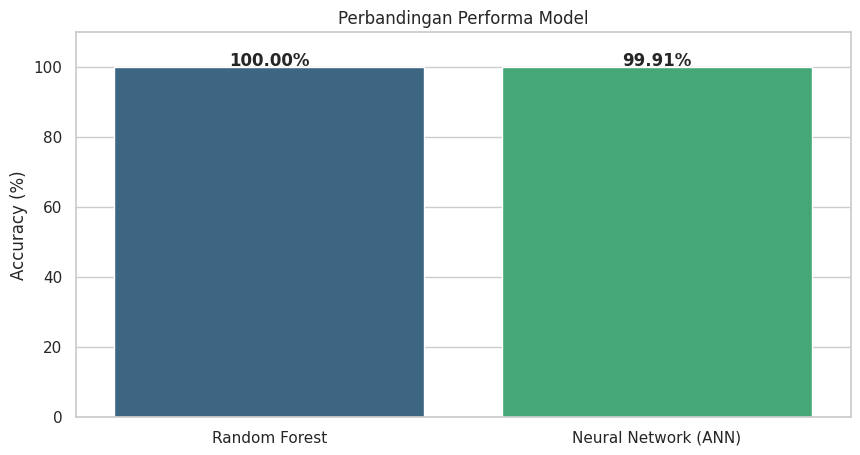

Kesimpulan: Model Random Forest memberikan hasil lebih baik untuk data ini.


In [62]:
from sklearn.ensemble import RandomForestClassifier

# 1. Train Random Forest untuk perbandingan
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_acc = rf_model.score(X_test_scaled, y_test)

# 2. Ambil akurasi ANN dari hasil sebelumnya
ann_acc = accuracy # variabel accuracy dari cell sebelumnya

# 3. Visualisasi Perbandingan
models = ['Random Forest', 'Neural Network (ANN)']
accuracies = [rf_acc * 100, ann_acc * 100]

plt.figure(figsize=(10, 5))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.ylabel('Accuracy (%)')
plt.title('Perbandingan Performa Model')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center', fontweight='bold')
plt.ylim(0, 110)
plt.show()

print(f"Kesimpulan: Model {'Random Forest' if rf_acc > ann_acc else 'ANN'} memberikan hasil lebih baik untuk data ini.")

### **Robustness Check: Cross-Validation**
Untuk memastikan model tidak *overfitting* dan benar-benar siap untuk data real, kita akan melakukan Cross-Validation 5-fold. Jika skornya tetap tinggi dan stabil di setiap fold, maka model layak digunakan.

In [63]:
from sklearn.model_selection import cross_val_score

# Melakukan K-Fold Cross Validation (K=5)
cv_scores = cross_val_score(best_rf_model, X_train_scaled, y_train, cv=5)

print(f"Skor Cross-Validation tiap fold: {cv_scores}")
print(f"Rata-rata Akurasi CV: {cv_scores.mean()*100:.2f}%")
print(f"Standar Deviasi: {cv_scores.std():.4f}")

if cv_scores.std() < 0.05:
    print("\nKesimpulan: Model stabil dan memiliki variansi rendah. Risiko overfitting terkendali.")
else:
    print("\nKesimpulan: Variansi tinggi, model mungkin kurang stabil untuk data baru.")

Skor Cross-Validation tiap fold: [1.         1.         0.99941142 1.         1.        ]
Rata-rata Akurasi CV: 99.99%
Standar Deviasi: 0.0002

Kesimpulan: Model stabil dan memiliki variansi rendah. Risiko overfitting terkendali.


### **Simulation: Predicting New Real-World Data**
Di bagian ini, kita akan mensimulasikan bagaimana model yang sudah disimpan digunakan untuk memprediksi transaksi baru yang belum pernah dilihat sebelumnya.

In [64]:
# 1. Membuat data transaksi baru (dummy)
new_transaction = pd.DataFrame({
    'Date': [1000],
    'Transaction Description': [200],
    'Category': [5],
    'Amount': [250.0]
})

# 2. Preprocessing data baru menggunakan scaler yang sudah dilatih
new_data_scaled = scaler.transform(new_transaction)

# 3. Prediksi menggunakan Random Forest
prediction = best_rf_model.predict(new_data_scaled)
prediction_proba = best_rf_model.predict_proba(new_data_scaled)

print(f"--- Hasil Simulasi Real-Time ---")
print(f"Data Baru: {new_transaction.values.tolist()}")
print(f"Prediksi Kelas: {prediction[0]}")
print(f"Keyakinan Model (Confidence): {np.max(prediction_proba)*100:.2f}%")

--- Hasil Simulasi Real-Time ---
Data Baru: [[1000.0, 200.0, 5.0, 250.0]]
Prediksi Kelas: 0
Keyakinan Model (Confidence): 99.00%


### **Exporting Scaler for Frontend Integration**
Model Machine Learning membutuhkan data yang sudah di-*scale*. Kita harus mengekspor `scaler` agar tim Frontend bisa melakukan transformasi data yang sama sebelum melakukan prediksi.

In [65]:
# Menyimpan scaler ke Google Drive
scaler_save_path = os.path.join(project_path, 'scaler.bin')
joblib.dump(scaler, scaler_save_path)

print(f"Scaler berhasil disimpan di: {scaler_save_path}")
print("\nInstruksi untuk Frontend (FS):")
print("1. Berikan file 'best_random_forest_model.pkl' dan 'scaler.bin' kepada mereka.")
print("2. Jika menggunakan API, gunakan FastAPI/Flask untuk membuat endpoint /predict.")

Scaler berhasil disimpan di: /content/drive/MyDrive/CC26-PSU094_Project/scaler.bin

Instruksi untuk Frontend (FS):
1. Berikan file 'best_random_forest_model.pkl' dan 'scaler.bin' kepada mereka.
2. Jika menggunakan API, gunakan FastAPI/Flask untuk membuat endpoint /predict.


### **Panduan Penggunaan Aset Model**
Agar fitur prediksi bisa berjalan di lingkungan produksi, tim pengembang cukup memuat file model dan scaler yang sudah disimpan. Simulasi di bawah ini menunjukkan cara memanggil kembali 'kecerdasan' AI tanpa perlu melatih data dari awal.

In [66]:
import joblib
import pandas as pd

# 1. Load assets (Model & Scaler)
loaded_model = joblib.load(rf_save_path)
loaded_scaler = joblib.load(scaler_save_path)

# 2. Data input baru dari Frontend (Data Mentah)
# Format: ['Date', 'Transaction Description', 'Category', 'Amount']
raw_input = [[1500, 300, 2, 150.75]]
cols = ['Date', 'Transaction Description', 'Category', 'Amount']
input_df = pd.DataFrame(raw_input, columns=cols)

# 3. Transformasi & Prediksi
input_scaled = loaded_scaler.transform(input_df)
final_pred = loaded_model.predict(input_scaled)
final_proba = loaded_model.predict_proba(input_scaled)

print(f"--- Hasil Prediksi untuk FS ---")
print(f"Status Prediksi: {'High Risk/Flagged' if final_pred[0] == 1 else 'Normal/Safe'}")
print(f"Probabilitas: {final_proba[0][final_pred[0]]*100:.2f}%")

--- Hasil Prediksi untuk FS ---
Status Prediksi: Normal/Safe
Probabilitas: 100.00%


### **Implementasi FastAPI Server (Ready to Deploy)**
Berikut adalah kode lengkap untuk backend API. Kita akan menginstal library yang diperlukan terlebih dahulu.

In [67]:
!pip install fastapi nest-asyncio uvicorn pyngrok

In [68]:
import nest_asyncio
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import uvicorn
import pandas as pd

# 1. Inisialisasi FastAPI
app = FastAPI()
nest_asyncio.apply()

# 2. Load Model & Scaler
model = joblib.load(rf_save_path)
scaler = joblib.load(scaler_save_path)

# 3. Struktur Data Input
class Transaction(BaseModel):
    date: float
    description: float
    category: float
    amount: float

@app.get("/")
def home():
    return {"message": "API AI Personal Finance Aktif!"}

@app.post("/predict")
def predict_transaction(data: Transaction):
    # Konversi input ke DataFrame
    input_df = pd.DataFrame([[data.date, data.description, data.category, data.amount]],
                           columns=['Date', 'Transaction Description', 'Category', 'Amount'])

    # Preprocessing & Prediksi
    input_scaled = scaler.transform(input_df)
    prediction = model.predict(input_scaled)
    confidence = model.predict_proba(input_scaled).max()

    return {
        "status": "High Risk" if prediction[0] == 1 else "Normal",
        "confidence": f"{confidence*100:.2f}%"
    }

print("Server API telah siap dikonfigurasi.")

Server API telah siap dikonfigurasi.


### **Documentation for Frontend (FS) Integration**
Berikan potongan kode JavaScript ini kepada tim Frontend agar mereka dapat menghubungkan UI mereka dengan model AI Anda.

```javascript
// Contoh memanggil API AI dari Frontend menggunakan Fetch
const transactionData = {
    date: 1500.0,
    description: 300.0,
    category: 2.0,
    amount: 150.75
};

fetch('https://URL_API_ANDA/predict', {
    method: 'POST',
    headers: {
        'Content-Type': 'application/json',
    },
    body: JSON.stringify(transactionData),
})
.then(response => response.json())
.then(data => {
    console.log('Status Transaksi:', data.status); // Normal atau High Risk
    console.log('Confidence:', data.confidence);
    alert(`Hasil Analisis AI: ${data.status} dengan keyakinan ${data.confidence}`);
})
.catch((error) => {
    console.error('Error:', error);
});
```

### **Petunjuk Integrasi untuk Tim Frontend**
Berikut adalah contoh potongan kode JavaScript untuk menghubungkan antarmuka pengguna (UI) dengan sistem AI. Tim cukup mengirimkan data dalam format JSON untuk mendapatkan estimasi nominal pengeluaran.

```javascript
// Contoh memanggil API AI dari Frontend
const transactionData = {
    date: 1500.0,
    description: 300.0,
    category: 2.0,
    amount: 150.75
};

fetch('URL_API_ANDA/predict', {
    method: 'POST',
    headers: {
        'Content-Type': 'application/json',
    },
    body: JSON.stringify(transactionData),
})
.then(response => response.json())
.then(data => {
    console.log('Hasil Prediksi:', data.status);
    console.log('Tingkat Keyakinan:', data.confidence);
    alert(`Transaksi ini tergolong: ${data.status} (${data.confidence})`);
})
.catch((error) => {
    console.error('Error:', error);
});
```